<a href="https://colab.research.google.com/github/24Sinchana/project/blob/main/Gold_price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt #to plot the graph
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics #evaluate the model

In [ ]:

#loading the csv data into the Panda dataframe
gold_dataset=pd.read_csv('/content/Gold_price.csv')

In [ ]:
gold_dataset.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [ ]:
gold_dataset.shape #number of rows and column

(2290, 6)

In [ ]:
#get the datatype of the data aand other basic info
gold_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [ ]:
#check missing values
gold_dataset.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [ ]:
#get statistical measure of the data
gold_dataset.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [ ]:
#analyze correlation(regression project)
#positive and negative correlation(inveresely proprtion)

In [ ]:
#remove non numeric column
gold_dataset_numeric = gold_dataset.select_dtypes(include=['float64', 'int64'])
#This argument specifies the data types you want to include in the filtered dataset.
# Calculate correlation
correlation = gold_dataset_numeric.corr()

<Axes: >

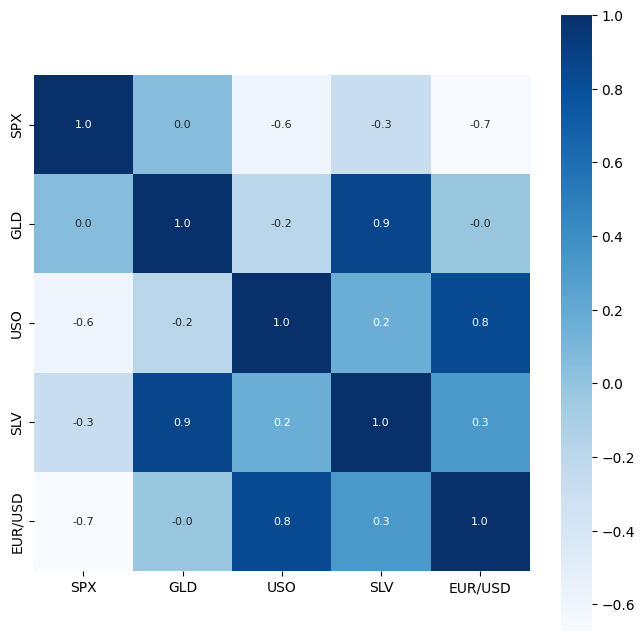

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [ ]:
#correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


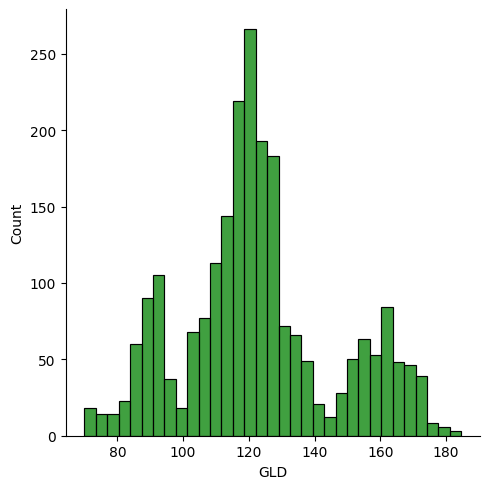

In [ ]:
#range of the Gold values
sns.displot(gold_dataset['GLD'],color='Green')

In [ ]:
#splitting of the data into the Label and features

In [ ]:
X=gold_dataset.drop(['Date','GLD'],axis=1)
Y=gold_dataset['GLD']

In [ ]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [ ]:
print(Y) #gold prices

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


splitting into train and test data

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

Model training

In [ ]:
regressor = RandomForestRegressor(n_estimators=100)

In [ ]:
regressor.fit(X_train,Y_train)


RandomForestRegressor()

In [ ]:
#prediction on tset data
test_data_prediction=regressor.predict(X_test)
print(test_data_prediction)

[168.82359987  82.05029972 116.13490049 127.48760059 120.930601
 154.72559738 150.43219875 126.24719974 117.46889876 125.93090087
 116.7520008  171.66430142 141.60699854 167.79019869 115.09699972
 117.68240068 138.5586026  169.75580109 158.95040289 160.54309975
 155.18220009 125.18690011 175.83039993 157.99120258 125.1968005
  94.01829993  77.93660018 120.33720007 119.07619917 167.44289965
  88.18610047 125.30860022  91.32420116 117.76930022 121.06489905
 135.74540042 115.44940127 115.07830073 147.83419998 107.20320116
 104.14460223  87.11989791 126.4203004  118.05650007 153.76599898
 119.64700023 108.47999955 108.11029821  93.19830061 127.12409756
  75.39030012 113.73849933 121.20559996 111.286399   118.87119879
 120.60889918 160.51020013 166.84020066 147.10349666  85.83559856
  94.40820028  86.8594988   90.47250016 119.02460075 126.42590081
 127.50110025 169.67969977 122.36069951 117.55009883  98.47870007
 168.01320058 143.20409857 131.54200174 121.27470229 121.24419962
 119.7097006 

In [ ]:
#metrics
#R squared error
error_score=metrics.r2_score(Y_test,test_data_prediction)
print("R squared error:",error_score)


R squared error: 0.9895781818393895


compare the actual values and predicted values


In [ ]:
Y_test = list(Y_test)

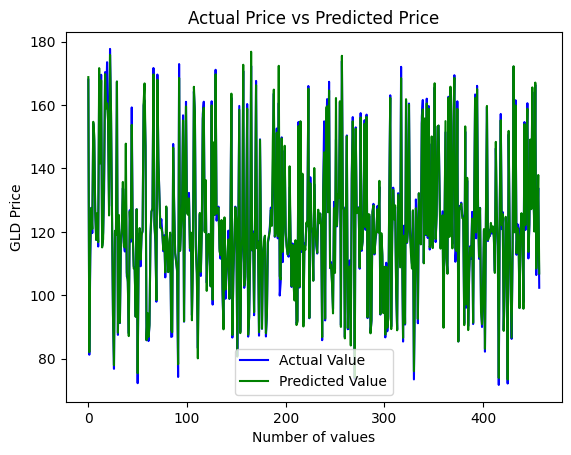

In [ ]:
plt.plot(Y_test,color='blue',label='Actual Value')
plt.plot(test_data_prediction,color='green',label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()# to plot

In [ ]:
#actual price is more than the preicted price